# 👕 Fashion Police Division
## FashionMNIST Image Classification Using Convolutional Neural Networks (CNNs)

### Project Overview

This project explores Computer Vision using Convolutional Neural Networks (CNNs) built with PyTorch.

The objective is to develop a deep learning model capable of classifying fashion products into one of ten categories using the FashionMNIST dataset.

Beyond model performance, this project focuses on understanding how CNNs learn visual features, evaluating model behavior through experimentation, and applying structured Machine Learning workflows to a Computer Vision problem.

### Project Goals

- Understand the fundamentals of CNNs
- Build and train CNN architectures using PyTorch
- Evaluate model performance using accuracy and confusion matrices
- Perform hypothesis-driven experimentation
- Analyze model strengths and weaknesses
- Document findings in a portfolio-ready format

### Final Project Outcome

✅ Built multiple CNN architectures

✅ Conducted experiments and hypothesis testing

✅ Analyzed model performance using a confusion matrix

✅ Achieved a final Test Accuracy of 90.08%

✅ Saved the trained model for future use

# Business Understanding

## Problem Statement

Image classification is one of the most common Computer Vision tasks and is widely used across industries.

Applications include:

- Product categorization in e-commerce
- Inventory management systems
- Visual search applications
- Recommendation systems
- Automated content tagging

The goal of this project is to develop a Convolutional Neural Network (CNN) capable of classifying fashion products into one of ten categories using image data.

---

## Project Objective

Develop and evaluate CNN architectures that can accurately classify FashionMNIST images while improving understanding of:

- Computer Vision workflows
- CNN architecture design
- Feature extraction
- Model evaluation
- Experimental hypothesis testing

---

## Success Criteria

The project will be considered successful if:

- A CNN can accurately classify clothing items from unseen images.
- Model performance can be evaluated using accuracy and confusion matrices.
- Experiments can be conducted to understand the impact of architectural and training choices.

---

# Dataset Overview

## Dataset Description

This project uses the FashionMNIST dataset, a benchmark Computer Vision dataset commonly used for image classification tasks.

The dataset was created as a more challenging replacement for the MNIST handwritten digits dataset and contains grayscale images of fashion products.

---

## Dataset Characteristics

| Feature | Value |
|----------|---------|
| Total Images | 70,000 |
| Training Images | 60,000 |
| Test Images | 10,000 |
| Image Size | 28 × 28 Pixels |
| Image Type | Grayscale |
| Number of Classes | 10 |

---

## Target Classes

| Label | Category |
|---------|-----------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle Boot |

---

## Why FashionMNIST?

FashionMNIST provides a practical introduction to Computer Vision because it contains real-world fashion products rather than handwritten digits.

The dataset allows experimentation with:

- Image Classification
- Feature Extraction
- Convolutional Neural Networks
- Model Evaluation
- Deep Learning Workflows

It also provides an opportunity to investigate how CNNs identify visual patterns and distinguish between different object categories.

---

# Import Libraries

The following libraries were used throughout the project for data handling, visualization, deep learning, and model evaluation.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# Load Dataset

The FashionMNIST dataset was loaded directly from the PyTorch torchvision library.

A tensor transformation was applied to convert image data into a format suitable for deep learning workflows.

In [2]:

transform = transforms.ToTensor()

train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)





100%|██████████| 26.4M/26.4M [00:01<00:00, 17.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 273kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.07MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.4MB/s]


# Exploratory Data Analysis (EDA)

Before building the CNN, the dataset was explored to understand its structure and characteristics.

The objectives of this analysis were:

- Verify image dimensions
- Explore class distribution
- Visualize sample images
- Identify potential classification challenges
- Understand the dataset before model training

In [3]:
print("Training Dataset Shape:", train_data.data.shape)
print("Test Dataset Shape:", test_data.data.shape)

Training Dataset Shape: torch.Size([60000, 28, 28])
Test Dataset Shape: torch.Size([10000, 28, 28])


In [4]:
from collections import Counter

class_counts = Counter(train_data.targets.tolist())

print(class_counts)

Counter({9: 6000, 0: 6000, 3: 6000, 2: 6000, 7: 6000, 5: 6000, 1: 6000, 6: 6000, 4: 6000, 8: 6000})


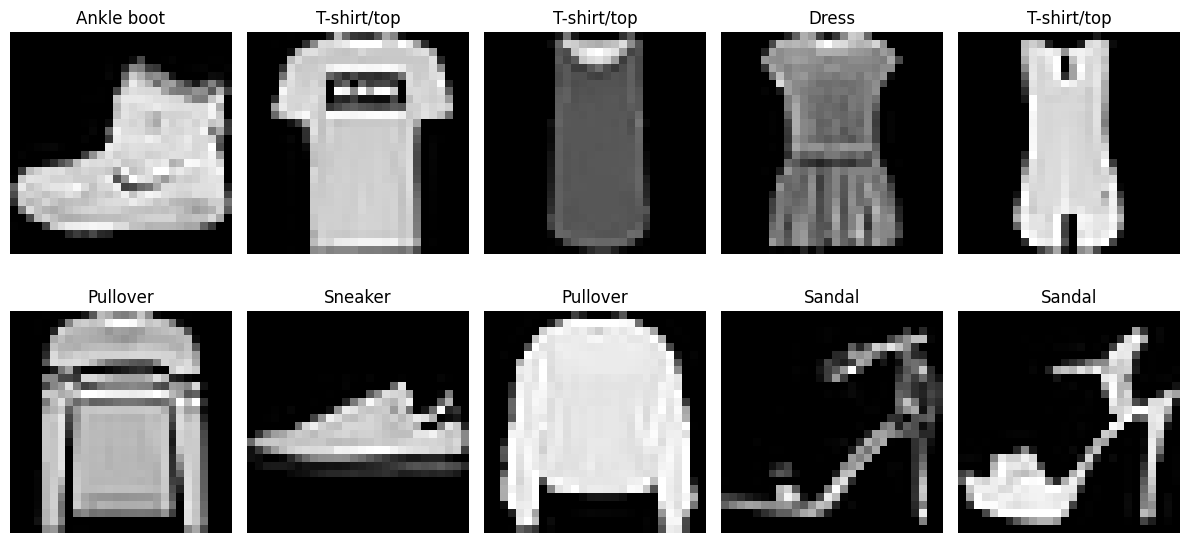

In [5]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

fig, axes = plt.subplots(2, 5, figsize=(12,6))

for i in range(10):
    image, label = train_data[i]

    axes[i//5, i%5].imshow(image.squeeze(), cmap="gray")
    axes[i//5, i%5].set_title(classes[label])
    axes[i//5, i%5].axis("off")

plt.tight_layout()
plt.show()


# EDA Findings

## Dataset Structure

The FashionMNIST dataset contains:

- 60,000 training images
- 10,000 test images
- Grayscale images
- Image dimensions of 28 × 28 pixels

This confirms that all images are standardized and suitable for CNN-based image classification.

---

## Class Distribution

Class distribution analysis showed that all ten classes contain exactly 6,000 training examples.

This indicates a perfectly balanced dataset and reduces the likelihood of performance issues caused by class imbalance.

---

## Visual Inspection Findings

Sample images revealed that:

- Footwear categories possess distinctive visual shapes.
- Bags appear visually different from most clothing categories.
- Several upper-body clothing categories share related visual structures.
- All images are centered and standardized.

These observations suggest that some categories may be easier to classify than others.

---

## Expected Modeling Challenges

Based on visual inspection alone, clothing items with related shapes may present a greater classification challenge than visually distinctive categories.

These observations were later investigated using confusion matrix analysis after model training.

---

# CNN Architecture

## Why Convolutional Neural Networks?

Traditional Neural Networks treat images as collections of individual pixels.

CNNs are specifically designed to learn visual patterns by automatically extracting relevant features from images.

This makes CNNs particularly effective for Computer Vision tasks such as image classification.

---

## Version 1 Architecture

The first CNN architecture consisted of a single convolutional block.

```text
Input Image
      ↓
Conv2D (1 → 32)
      ↓
ReLU
      ↓
MaxPool
      ↓
Flatten
      ↓
Linear
      ↓
Prediction
```

### CNN Layer Interpretation

Conv2D → Feature extraction

ReLU → Non-linear activation

MaxPool → Spatial compression

Flatten → Convert feature maps into a vector

Linear → Final classification

---

## Version 2 Architecture

To investigate whether a deeper network would improve performance, a second convolution block was added.

```text
Input Image
      ↓
Conv2D (1 → 32)
      ↓
ReLU
      ↓
MaxPool

      ↓

Conv2D (32 → 64)
      ↓
ReLU
      ↓
MaxPool

      ↓

Flatten
      ↓
Linear
      ↓
Prediction
```

---

## Detective Interpretation 🕵🏽‍♀️

During the learning process, the CNN was understood using the following analogy:

```text
Conv2D
↓
Detectives gather evidence

ReLU
↓
Ignore weak clues

MaxPool
↓
Compress evidence

Flatten
↓
Prepare the case file

Linear
↓
Judges deliver the verdict
```

This analogy helped simplify the flow of information through the CNN and build intuition around feature extraction.

# Data Preparation

Before training the CNN, the dataset was prepared for efficient deep learning workflows.

A tensor transformation was applied during dataset loading, converting image data into a PyTorch-compatible format.

The next step involved creating DataLoader objects to:

- Load images in batches
- Improve training efficiency
- Shuffle training data
- Feed images into the CNN during training

---

## Training Data

- Batch Size: 64
- Shuffle: True

Training data was shuffled to help the model learn general patterns rather than image ordering.

---

## Test Data

- Batch Size: 64
- Shuffle: False

Test data remained in its original order to ensure consistent evaluation.

In [6]:
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

# CNN Version 1: Building the First Detective Squad

The first CNN architecture was intentionally designed to be simple.

The goal was to understand the fundamental building blocks of Convolutional Neural Networks before experimenting with deeper architectures.

The model consists of:

- One Convolution Layer
- ReLU Activation
- Max Pooling
- Flatten Layer
- Fully Connected Layer

This architecture serves as a baseline model for evaluating the impact of architectural improvements.

---

## Architecture Summary

```text
Input Image
      ↓
Conv2D (1 → 32)
      ↓
ReLU
      ↓
MaxPool
      ↓
Flatten
      ↓
Linear
      ↓
Prediction
```

In [7]:
class FashionDetectiveCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(5408, 10)

    def forward(self, x):

        x = self.conv1(x)

        x = self.relu(x)

        x = self.pool(x)

        x = self.flatten(x)

        x = self.fc1(x)

        return x

## Architecture Interpretation

The first convolution layer produces 32 feature maps that capture low-level image features such as edges, curves, and simple patterns.

After pooling and flattening, the extracted features are passed to a fully connected layer for final classification.

### Detective Interpretation

```text
Conv2D
↓
Detectives gather evidence

ReLU
↓
Ignore weak clues

MaxPool
↓
Compress evidence

Flatten
↓
Prepare the case file

Linear
↓
Judges deliver the verdict
```

# CNN Version 1 Training

After defining the baseline CNN architecture, the model was trained using the FashionMNIST training dataset.

The objective of this first experiment was to establish a performance baseline before introducing additional architectural complexity.

---

## Training Configuration

### Loss Function

```python
CrossEntropyLoss()
```

CrossEntropyLoss was selected because this is a multi-class image classification problem.

### Optimizer

```python
Adam
```

The Adam optimizer was used to update model parameters during training.

### Epochs

```text
5 Epochs
```

The model was initially trained for five epochs to evaluate baseline performance.

In [8]:
model = FashionDetectiveCNN()

print(model)

FashionDetectiveCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=5408, out_features=10, bias=True)
)


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [11]:
epochs = 5

for epoch in range(epochs):

    running_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

Epoch 1/5, Loss: 444.0005
Epoch 2/5, Loss: 309.4630
Epoch 3/5, Loss: 273.8905
Epoch 4/5, Loss: 251.4724
Epoch 5/5, Loss: 235.8730


In [12]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 89.36%


# CNN Version 1 Results

The baseline CNN was trained for 5 epochs using the FashionMNIST training dataset.

### Training Performance

| Epoch | Loss |
|---------|---------|
| 1 | 444.0005 |
| 2 | 309.4630 |
| 3 | 273.8905 |
| 4 | 251.4724 |
| 5 | 235.8730 |

---

## Test Accuracy

```text
89.36%
```

### Observations

- Training loss decreased consistently across all epochs.
- The CNN successfully learned useful image representations from the training data.
- The model achieved strong baseline performance despite having only a single convolutional layer.

This baseline model provides a reference point for evaluating more complex CNN architectures.

# CNN Version 2: Upgrading the Detective Squad

After establishing a baseline model, a second convolutional layer was introduced to investigate whether a deeper architecture could improve classification performance.

The objective was to allow the model to learn increasingly complex visual patterns by adding an additional feature extraction stage.

---

## Motivation

The first CNN architecture successfully learned basic image features and achieved strong performance.

The next question was:

> Can a deeper CNN learn richer visual representations and improve classification accuracy?

To answer this question, a second convolutional layer was added.

---

## Expected Advantage

The first convolution layer extracts simple visual patterns such as:

- Edges
- Curves
- Basic shapes

The second convolution layer can then learn more complex patterns from those previously extracted features.

This creates a hierarchical learning process where the CNN gradually builds more sophisticated image representations.

In [13]:
class FashionDetectiveCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)

        self.conv2 = nn.Conv2d(32, 64, 3)

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(1600, 10)

    def forward(self, x):

        x = self.conv1(x)

        x = self.relu(x)

        x = self.pool(x)

        x = self.conv2(x)

        x = self.relu(x)

        x = self.pool(x)

        x = self.flatten(x)

        x = self.fc1(x)

        return x

In [14]:
model = FashionDetectiveCNN()

print(model)

FashionDetectiveCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1600, out_features=10, bias=True)
)


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [16]:
epochs = 10

for epoch in range(epochs):

    running_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

Epoch 1/10, Loss: 494.1879
Epoch 2/10, Loss: 333.1004
Epoch 3/10, Loss: 292.6861
Epoch 4/10, Loss: 265.4116
Epoch 5/10, Loss: 245.7196
Epoch 6/10, Loss: 229.3937
Epoch 7/10, Loss: 217.9230
Epoch 8/10, Loss: 206.3483
Epoch 9/10, Loss: 195.3444
Epoch 10/10, Loss: 186.9697


In [17]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 90.11%


# CNN Version 2 Results

The upgraded CNN architecture was trained for 10 epochs.

### Training Performance

| Epoch | Loss |
|---------|---------|
| 1 | 494.1879 |
| 2 | 333.1004 |
| 3 | 292.6861 |
| 4 | 265.4116 |
| 5 | 245.7196 |
| 6 | 229.3937 |
| 7 | 217.9230 |
| 8 | 206.3483 |
| 9 | 195.3444 |
| 10 | 186.9697 |

---

## Test Accuracy

```text
90.11%
```

---

## Comparison with CNN Version 1

| Model | Accuracy |
|----------|----------|
| CNN Version 1 | 89.36% |
| CNN Version 2 | 90.11% |

### Improvement

```text
+0.75%
```

The additional convolution layer combined with increased training time produced a measurable improvement in classification performance.

---

## Key Observation

The deeper architecture did not immediately outperform the baseline model.

Performance improvements only became apparent after extending the training process, demonstrating the importance of sufficient training duration when working with more complex neural network architectures.

# Model Evaluation & Analysis

Model evaluation was performed using:

- Test Accuracy
- Confusion Matrix Analysis
- Individual Predictions

While overall accuracy provides a high-level measure of performance, confusion matrix analysis helps identify specific classes that the model struggles to classify correctly.

This provides deeper insight into model strengths and weaknesses.

# Confusion Matrix Analysis

A confusion matrix was generated to investigate classification errors.

The confusion matrix provided a detailed view of:

- Correct predictions
- Misclassifications
- Classes that were frequently confused

This analysis helped identify areas where the model performed well and where improvements may still be needed.
`

In [18]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())

        all_labels.extend(labels.numpy())

In [19]:
cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[787   0  18  38   2   0 144   0  11   0]
 [  1 971   1  23   1   0   1   0   2   0]
 [ 18   0 853  12  30   0  83   0   4   0]
 [  4   0   9 951  10   0  22   0   4   0]
 [  2   0  62  41 776   0 110   0   9   0]
 [  0   0   0   0   0 983   0  10   1   6]
 [ 75   0  44  42  48   0 773   0  18   0]
 [  0   0   0   0   0  15   0 951   2  32]
 [  0   0   3   5   1   1   1   0 988   1]
 [  1   0   0   0   0   6   0  15   0 978]]


# Confusion Matrix Analysis

A confusion matrix was generated to evaluate how well the CNN classified each clothing category.

Rather than focusing only on overall accuracy, the confusion matrix provides detailed insight into which classes were correctly identified and which classes were frequently misclassified.

This helps reveal model strengths and weaknesses that overall accuracy alone cannot capture.

---

# Confusion Matrix Findings

## Strongly Classified Categories

The model performed exceptionally well on:

- Trouser
- Sandal
- Sneaker
- Bag
- Ankle Boot

These categories achieved very high classification accuracy and were rarely confused with other classes.

Their distinctive visual characteristics likely contributed to their strong performance.

---

## Frequently Confused Categories

The model experienced the most difficulty distinguishing between:

- T-shirt/top
- Shirt
- Pullover
- Coat

Several misclassifications occurred among these upper-body clothing categories.

This suggests that certain clothing items share similar visual patterns, making them more challenging for the CNN to distinguish.

---

## Notable Misclassifications

Examples observed in the confusion matrix include:

- T-shirt/top classified as Shirt
- Coat classified as Shirt
- Pullover classified as Shirt
- Shirt classified as T-shirt/top

These findings indicate that the model struggled most with visually related upper-body garments.

---

## Key Observation

Although the model achieved a test accuracy of 90.11%, the confusion matrix revealed that performance was not uniform across all categories.

Distinctive categories such as footwear and bags were classified very effectively, while visually similar clothing items remained challenging.

This demonstrates the importance of supplementing accuracy metrics with confusion matrix analysis when evaluating machine learning models.

In [20]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [21]:
image, label = test_data[0]

with torch.no_grad():

    prediction = model(image.unsqueeze(0))

    predicted_class = torch.argmax(prediction, dim=1).item()

print("Actual:", classes[label])
print("Predicted:", classes[predicted_class])

Actual: Ankle boot
Predicted: Ankle boot


# Prediction Lab

Beyond aggregate evaluation metrics, individual predictions were examined to determine whether the model could correctly classify unseen fashion items.

This provides a practical demonstration of the CNN's ability to generalize beyond the training data.

---

## Example Prediction

```text
Actual: Ankle Boot 👢
Predicted: Ankle Boot 👢
```

✅ Correct Classification

The model successfully identified the test image and produced the correct prediction.

This demonstrates the model's ability to perform image classification on previously unseen data.

---

## Why Prediction Testing Matters

Accuracy and confusion matrices provide high-level evaluation metrics.

Prediction testing allows direct inspection of model behavior on individual images and helps verify that the model performs as expected in practical scenarios.

# Key Learnings

- CNNs learn hierarchical visual features.
- More layers do not automatically improve performance.
- Additional model complexity may require additional training.
- Confusion matrices reveal insights hidden by accuracy metrics.
- Experimental validation is essential in machine learning workflows.

# Future Improvements

Several enhancements could be explored to improve model performance further.

## Model Improvements

- Increase training duration
- Experiment with additional CNN layers
- Tune learning rates
- Optimize batch sizes

## Regularization Techniques

- Dropout
- Batch Normalization

## Data Improvements

- Data Augmentation
- Image Transformations

## Advanced Architectures

Future experiments could explore:

- ResNet
- Transfer Learning
- Pre-trained Computer Vision Models

# Project Conclusion

This project successfully demonstrated the application of Convolutional Neural Networks (CNNs) to a Computer Vision classification problem using the FashionMNIST dataset.

Key outcomes include:

- Successful implementation of CNN architectures using PyTorch.
- Evaluation of model performance through accuracy and confusion matrix analysis.
- Experimental comparison between baseline and deeper CNN architectures.
- Validation of a hypothesis regarding training duration and model performance.
- Achievement of a final test accuracy of **90.11%**.

Beyond model performance, this project provided practical experience in Deep Learning workflows, experimentation, performance evaluation, and evidence-based decision making.

The project reinforced the importance of understanding model behavior rather than focusing solely on final accuracy metrics.